# Automatic Differentiation - Baseline

We will start illustrating the use of **Automatic Differentiation** for some known simple functions using `pyTorch`.

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

In [2]:
plt.style.use('dark_background')

# Automatic Differentiation by Example:

## Simple Function 1: $f(x)=\sin(x)$

In [3]:
x = torch.arange(0,2*np.pi,0.01)
x.requires_grad = True
x.grad

The gradient is `None` by default, that is why we do not get any output from the last cell.

Now, let us define the function we are interested in finding its derivative:

In [4]:
y = torch.sin(x)

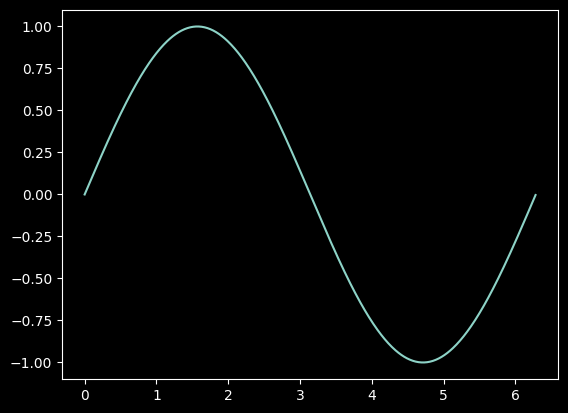

In [5]:
f, ax = plt.subplots(dpi=100)
ax.plot(x.detach().numpy(),y.detach().numpy())
plt.show()

### Automatic Differentiation
Now, let us numerically compute the derivative of $y$ with respect to $x$, this is:
$$\dfrac{dy}{dx} = \cos(x)$$

In [6]:
# Essentially we compute the derivate for each point in the vector
for i in range(len(y)):
    y[i].backward(retain_graph=True)

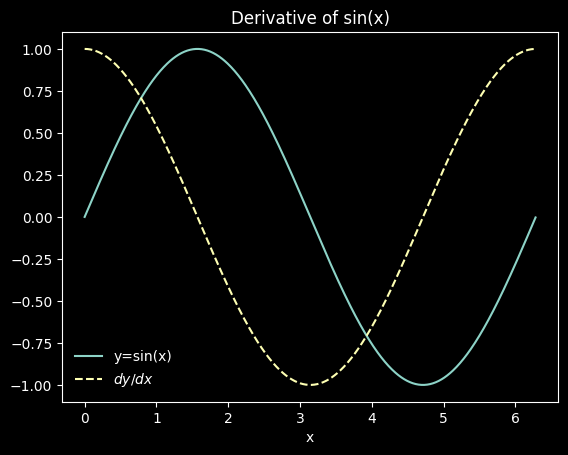

In [7]:
f, ax = plt.subplots(dpi=100)
ax.plot(x.detach().numpy(),y.detach().numpy(), label='y=sin(x)')
ax.plot(x.detach().numpy(), x.grad.numpy(), label=r'$dy/dx$', linestyle='--')
ax.set_title('Derivative of sin(x)')
ax.set_xlabel('x')
ax.legend(loc='best', frameon=False)
plt.show()

So, we see that the autograd method works pretty well for this simple function

## (Not so) simple function 2: 
$$f(x)=((\log x^2)\sin(x))+ x^{-1}$$
Its derivative is given by:

$$f^{\prime}(x)=\dfrac{2}{x}\sin (x)+ (\log x^2)\cos(x)-\dfrac{1}{x^2} $$

In [8]:
def func2(x):
    """
    Compute the expression log(x**2) * sin(x) + x^(-1) using PyTorch operations.

    Parameters:
    ----------
    x : torch.Tensor
        A PyTorch tensor input.

    Returns:
    -------
    torch.Tensor
        The computed result as a PyTorch tensor.
    """
    return torch.log(x**2) * torch.sin(x) + torch.pow(x, -1)

def derivative_f(x):
    """
    Compute the derivative of f(x) = (log(x^2) * sin(x)) + x^(-1)
    using PyTorch operations.

    Parameters:
    ----------
    x : torch.Tensor
        Input tensor of real numbers.

    Returns:
    -------
    torch.Tensor
        The derivative of f(x) with respect to x.
    """
    # Compute individual terms of the derivative
    term1 = (2 / x) * torch.sin(x)                 # 2/x * sin(x)
    term2 = torch.log(x**2) * torch.cos(x)         # log(x^2) * cos(x)
    term3 = -1 / (x**2)                            # -1 / x^2

    # Combine terms to get the derivative
    df_dx = term1 + term2 + term3
    return df_dx

In [9]:
x = torch.arange(-5, 5, 0.01, dtype=torch.float32)

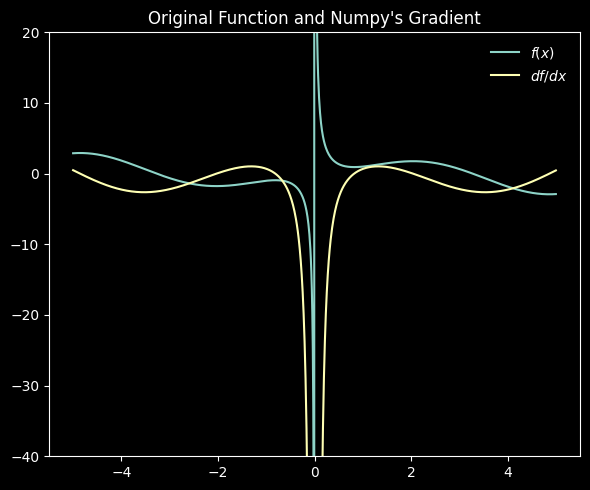

In [10]:
fig, ax = plt.subplots(dpi=100, figsize=(6,5))
ax.plot(x.detach().numpy(), func2(x).detach().numpy(), label=r'$f(x)$')
# ax.plot(x.detach().numpy(), np.gradient(func2(x).detach().numpy(), x.detach().numpy()), label='np gradient')
ax.plot(x.detach().numpy(), derivative_f(x).detach().numpy(), label=r'$df/dx$')
ax.set_title("Original Function and Numpy's Gradient")
ax.legend(loc='best', frameon=False)
ax.set_ylim(-40, 20)
fig.tight_layout()
plt.show()

In [11]:
x = torch.arange(-5, 5, 0.01, dtype=torch.float32)
x.requires_grad = True
x.grad

In [12]:
y = func2(x)
y.backward(gradient=torch.ones(len(y)))

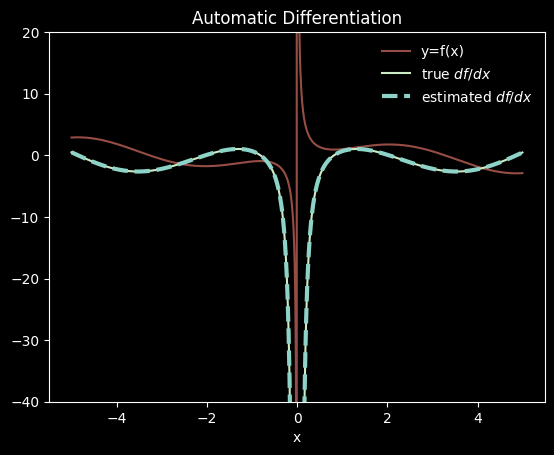

In [35]:
f, ax = plt.subplots(dpi=100)
ax.plot(x.detach().numpy(),y.detach().numpy(), label='y=f(x)', alpha=0.6, c="C3")
ax.plot(x.detach().numpy(), derivative_f(x).detach().numpy(), label=r'true $df/dx$', color='C8')
ax.plot(x.detach().numpy(), x.grad.numpy(), label=r'estimated $df/dx$', linestyle='--', lw=3, color='C0')
ax.set_title('Automatic Differentiation')
ax.set_xlabel('x')
ax.legend(loc='best', frameon=False)
ax.set_ylim(-40, 20)
plt.show()

# Random Noise Effect
Real life is harsh and full of noise. To have an idea of the effect of noise on the automatic differentiation procedure we will add a gaussian noise term to the data generation process and perform the autodiff estimation on top of this noisy set of data points. 

## Simple function: `f(x)=sin(x)`

In [36]:
import torch

def generate_noisy_data(x, func, noise_std=0.1):
    """
    Generate data by applying a user-defined function to x and adding random noise.

    Parameters:
    ----------
    x : torch.Tensor
        A tensor of input values (real numbers).
    func : callable
        A Python function that takes a tensor as input and returns a tensor as output.
    noise_std : float, optional
        The standard deviation of the Gaussian noise to add. Default is 0.1.

    Returns:
    -------
    torch.Tensor
        The noisy output values.
    """
    # Apply the user-defined function
    y = func(x)
    
    # Generate random noise
    noise = torch.randn_like(x) * noise_std
    
    # Add noise to the function output
    y_noisy = y + noise
    
    return y_noisy


In [37]:
x = torch.arange(0,2*np.pi,0.01)
x.requires_grad = True
x.grad
y = generate_noisy_data(x, torch.sin, 0.3)

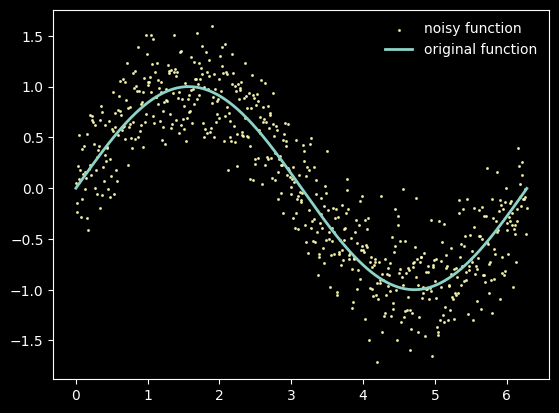

In [38]:
f, ax = plt.subplots(dpi=100)
ax.scatter(x.detach().numpy(),y.detach().numpy(), label="noisy function", alpha=0.8, marker='.', s=5, color="C1")
ax.plot(x.detach().numpy(), torch.sin(x).detach().numpy(), label="original function", lw=2)
ax.legend(loc="best", frameon=False)
plt.show()

In [39]:
y.backward(gradient=torch.ones(len(y)))

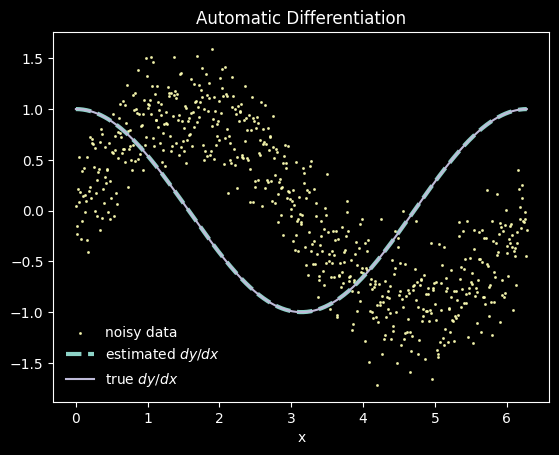

In [40]:
f, ax = plt.subplots(dpi=100)
ax.scatter(x.detach().numpy(),y.detach().numpy(), label="noisy data", alpha=0.8, marker='.', s=5, color="C1")
ax.plot(x.detach().numpy(), x.grad.numpy(), label=r'estimated $dy/dx$', linestyle='--', lw=3)
# ax.plot(x.detach().numpy(), np.gradient(torch.sin(x).detach().numpy(), x.detach().numpy()), label='np gradient')
ax.plot(x.detach().numpy(), torch.cos(x).detach().numpy(), label=r'true $dy/dx$', linestyle='-', c="C2")
ax.set_title('Automatic Differentiation')
ax.set_xlabel('x')
ax.legend(loc='best', frameon=False)
plt.show()

The estimated derivative is still perfectly matching the true derivative since pyTorch is computing the derivative of the source function (sin). What we need to do in order to approximate the derivative from a NN is to estimate the original function using a NN and then estimate the derivative using automatic differentiation, this is done in the next section.

# Using a Neural Network to approximate `sin(x)`

In [41]:
import torch
import torch.nn as nn
import torch.optim as optim


In [42]:
# Generate synthetic data with noise
torch.manual_seed(42)
x = torch.linspace(0, 2*np.pi, 1000).unsqueeze(1)
y = torch.sin(x) + 0.1*torch.randn(x.shape)  # y = sin(x) + noise

In [43]:
# Define neural network architecture
class SineApproximator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 128),
            nn.Tanh(),
            nn.Linear(128, 128),
            nn.Tanh(),
            nn.Linear(128, 1)
        )
    
    def forward(self, x):
        return self.net(x)


In [44]:
model = SineApproximator()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

In [45]:

# Improved training loop with gradient accumulation
epochs = 2000
for epoch in range(epochs):
    optimizer.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    
    # Single backward pass for all parameters
    loss.backward()
    optimizer.step()

## First derivative estimation

In [46]:
# Vectorized derivative calculation using autograd.grad
x_eval = torch.linspace(0, 2*np.pi, 1000, requires_grad=True).unsqueeze(1)
y_pred = model(x_eval)

# Compute gradients using torch.autograd.grad
dy_dx = torch.autograd.grad(
    outputs=y_pred,
    inputs=x_eval,
    grad_outputs=torch.ones_like(y_pred),  # Gradient "weights" for outputs
    create_graph=False,  # No need to retain the graph
    retain_graph=False   # Save memory
)[0]  # Returns a tuple; [0] gets the gradients

# Detach for visualization
x_plot = x_eval.detach().numpy()
dy_dx = dy_dx.detach().numpy()

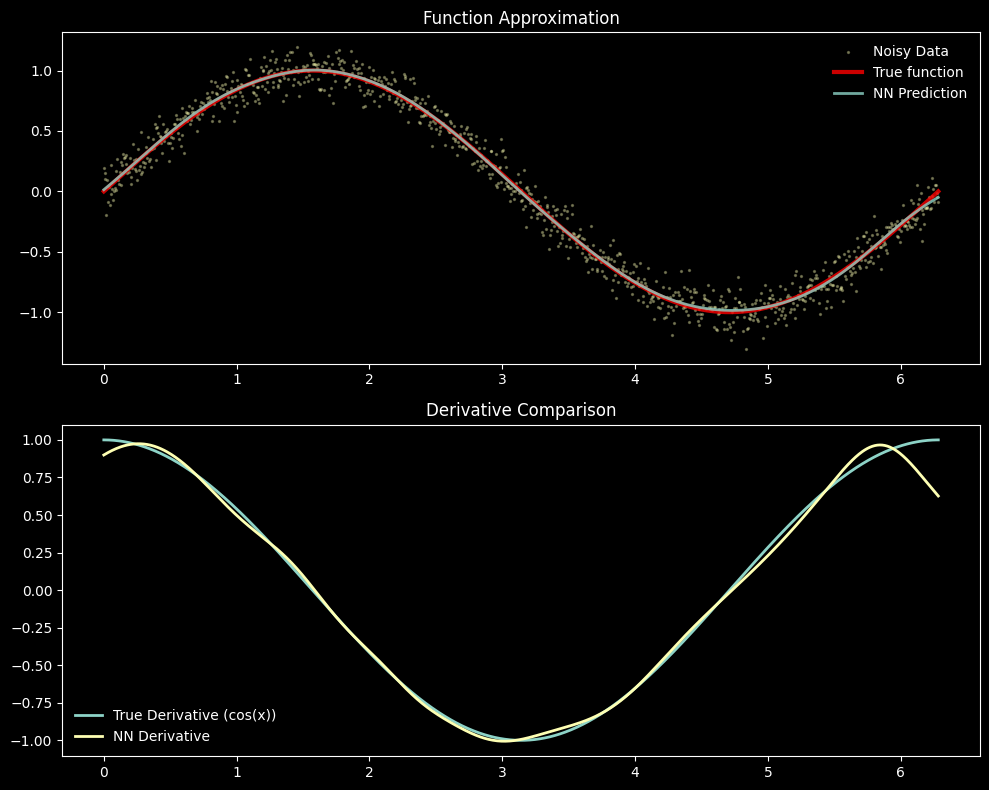

In [49]:

# Plot results
plt.figure(figsize=(10, 8))

plt.subplot(2, 1, 1)
plt.scatter(x, y, s=2, label='Noisy Data', color="C1", alpha=0.3)
plt.plot(x_plot, np.sin(x_plot), 'r', label='True function', alpha=0.8, linewidth=3)
plt.plot(x_plot, y_pred.detach().numpy(), label='NN Prediction', linewidth=2, alpha=0.8)
plt.title('Function Approximation')
plt.legend(frameon=False)

plt.subplot(2, 1, 2)
plt.plot(x_plot, np.cos(x_plot), label='True Derivative (cos(x))', linewidth=2)
plt.plot(x_plot, dy_dx, label='NN Derivative', linewidth=2)
plt.title('Derivative Comparison')
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

Note that the derivative estimate is quite good far from the boundaries. NNs tend to perform well in regions where training data is dense but can have significant errors near boundaries due to limited information outside the interval. At boundaries, NNs have less context from both sides beyond the boundaries

## Computing the second derivative

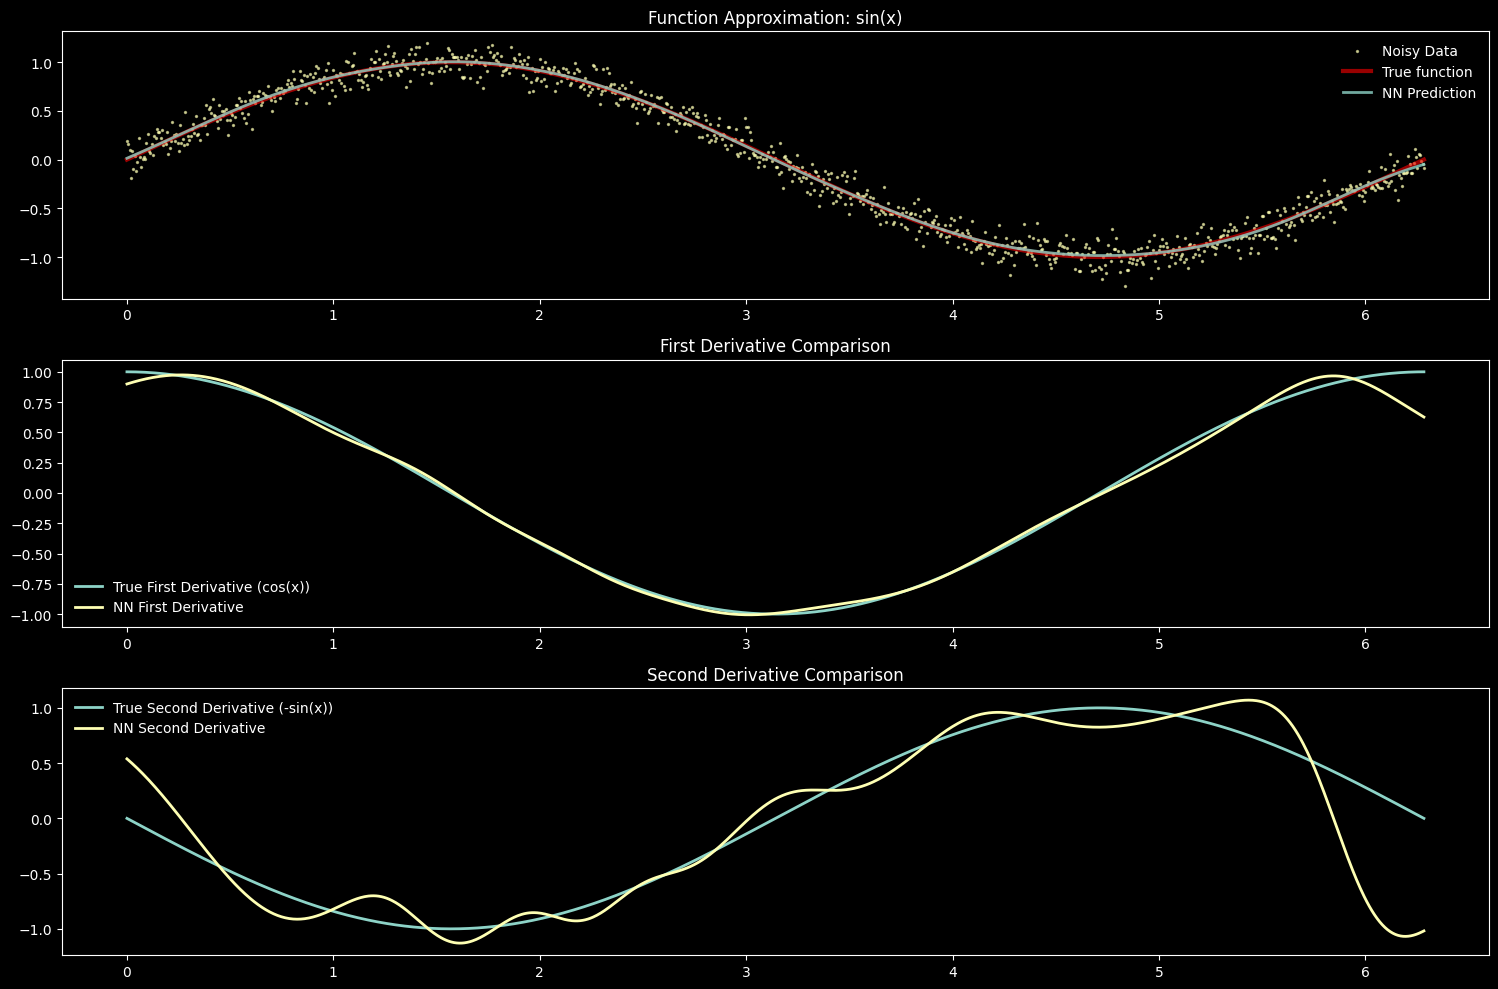

In [75]:
# Computing second derivative requires create_graph=True for the first derivative
x_eval = torch.linspace(0, 2*np.pi, 1000, requires_grad=True).unsqueeze(1)
y_pred = model(x_eval)

# First derivative with create_graph=True to enable higher-order derivatives
dy_dx = torch.autograd.grad(
    outputs=y_pred,
    inputs=x_eval,
    grad_outputs=torch.ones_like(y_pred),
    create_graph=True,  # Enable computation of higher-order derivatives
    retain_graph=True
)[0]

# Second derivative
d2y_dx2 = torch.autograd.grad(
    outputs=dy_dx,
    inputs=x_eval,
    grad_outputs=torch.ones_like(dy_dx),
    create_graph=False,
    retain_graph=False
)[0]

# Plot results
plt.figure(figsize=(15, 10))

plt.subplot(3, 1, 1)
plt.scatter(x.detach().numpy(), y.detach().numpy(), s=2, label='Noisy Data', color="C1", alpha=0.6)
plt.plot(x_eval.detach().numpy(), np.sin(x_eval.detach().numpy()), 'r', label='True function', alpha=0.6, linewidth=3)
plt.plot(x_eval.detach().numpy(), y_pred.detach().numpy(), label='NN Prediction', linewidth=2, alpha=0.8)
plt.title('Function Approximation: sin(x)')
plt.legend(frameon=False)

plt.subplot(3, 1, 2)
plt.plot(x_eval.detach().numpy(), np.cos(x_eval.detach().numpy()), label='True First Derivative (cos(x))', linewidth=2)
plt.plot(x_eval.detach().numpy(), dy_dx.detach().numpy(), label='NN First Derivative', linewidth=2)
plt.title('First Derivative Comparison')
plt.legend(frameon=False)

plt.subplot(3, 1, 3)
plt.plot(x_eval.detach().numpy(), -np.sin(x_eval.detach().numpy()), label='True Second Derivative (-sin(x))', linewidth=2)
plt.plot(x_eval.detach().numpy(), d2y_dx2.detach().numpy(), label='NN Second Derivative', linewidth=2)
plt.title('Second Derivative Comparison')
plt.legend(frameon=False)

plt.tight_layout()
plt.show()

Note that the second derivative estimate is quite noisy and unstable. Is there any way of improving this estimate?

# Improving Second Derivative Estimates

There are several techniques to improve the stability and accuracy of second derivative estimates:

### 1. **Regularization During Training**
Adding regularization terms that penalize high-frequency oscillations can lead to smoother learned functions.

### 2. **Ensemble Methods**
Training multiple networks and averaging their derivatives can reduce noise.

### 3. **Sobolev Training**
Including derivative information in the loss function during training.

### 4. **Post-Processing Smoothing**
Applying smoothing filters to the computed derivatives.

### 5. **Architectural Choices**
Using activation functions with smoother higher-order derivatives.

Let's implement and compare some of these approaches:

In [ ]:

class SmoothSineApproximator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.net(x)

def sobolev_loss(model, x, y, lambda_reg=0.01):
    """
    Compute loss that includes derivative regularization
    """
    # x.requires_grad_(True)
    y_pred = model(x)
    
    # Standard MSE loss
    mse_loss = nn.MSELoss()(y_pred, y)
    
    # Compute first derivative
    dy_dx = torch.autograd.grad(
        outputs=y_pred,
        inputs=x,
        grad_outputs=torch.ones_like(y_pred),
        create_graph=True,
        retain_graph=True,
        only_inputs=True  # This can help with memory efficiency
    )[0]
    
    # True first derivative for sin(x) is cos(x)
    true_dy_dx = torch.cos(x)
    derivative_loss = nn.MSELoss()(dy_dx, true_dy_dx)
    
    # Combined loss
    total_loss = mse_loss + lambda_reg * derivative_loss
    return total_loss, mse_loss, derivative_loss

# Train model with Sobolev regularization
torch.manual_seed(42)
smooth_model = SmoothSineApproximator()
smooth_optimizer = optim.Adam(smooth_model.parameters(), lr=0.005)

epochs = 3000
for epoch in range(epochs):
    smooth_optimizer.zero_grad()
    
    # Create fresh training data each epoch to avoid graph conflicts
    x_train = torch.linspace(0, 2*np.pi, 1000, requires_grad=True).unsqueeze(1)
    y_train = torch.sin(x_train) + 0.1*torch.randn(x_train.shape)
    
    loss, mse_loss, deriv_loss = sobolev_loss(smooth_model, x_train, y_train, lambda_reg=0.2)
    loss.backward()
    smooth_optimizer.step()
    
    if epoch % 500 == 0:
        print(f'Epoch {epoch}: Total Loss = {loss.item():.6f}, MSE = {mse_loss.item():.6f}, Deriv = {deriv_loss.item():.6f}')

In [68]:
def train_ensemble(n_models=5):
    """Train an ensemble of neural networks"""
    models = []
    
    for i in range(n_models):
        torch.manual_seed(42 + i)  # Different initialization for each model
        model = SineApproximator()
        optimizer = optim.Adam(model.parameters(), lr=0.005)
        
        # Slightly different training data for each model
        x_train = torch.linspace(0, 2*np.pi, 1000).unsqueeze(1)
        y_train = torch.sin(x_train) + 0.1*torch.randn(x_train.shape)
        
        # Train the model
        for epoch in range(2000):
            optimizer.zero_grad()
            outputs = model(x_train)
            loss = nn.MSELoss()(outputs, y_train)
            loss.backward()
            optimizer.step()
        
        models.append(model)
        print(f"Trained model {i+1}/{n_models}")
    
    return models

def ensemble_derivatives(models, x_eval):
    """Compute ensemble average of derivatives"""
    all_derivatives = []
    all_second_derivatives = []
    
    for model in models:
        model.eval()
        x_eval.requires_grad_(True)
        y_pred = model(x_eval)
        
        # First derivative
        dy_dx = torch.autograd.grad(
            outputs=y_pred,
            inputs=x_eval,
            grad_outputs=torch.ones_like(y_pred),
            create_graph=True,
            retain_graph=True
        )[0]
        
        # Second derivative
        d2y_dx2 = torch.autograd.grad(
            outputs=dy_dx,
            inputs=x_eval,
            grad_outputs=torch.ones_like(dy_dx),
            create_graph=False,
            retain_graph=False
        )[0]
        
        all_derivatives.append(dy_dx.detach())
        all_second_derivatives.append(d2y_dx2.detach())
    
    # Average across ensemble
    avg_first_deriv = torch.stack(all_derivatives).mean(dim=0)
    avg_second_deriv = torch.stack(all_second_derivatives).mean(dim=0)
    
    return avg_first_deriv, avg_second_deriv

# Train ensemble
print("Training ensemble of models...")
ensemble_models = train_ensemble(n_models=5)  # Using 3 for faster computation

Epoch 0: Total Loss = 0.652059, MSE = 0.552999, Deriv = 0.495301
Epoch 500: Total Loss = 0.010500, MSE = 0.010469, Deriv = 0.000156
Epoch 500: Total Loss = 0.010500, MSE = 0.010469, Deriv = 0.000156
Epoch 1000: Total Loss = 0.010464, MSE = 0.010423, Deriv = 0.000208
Epoch 1000: Total Loss = 0.010464, MSE = 0.010423, Deriv = 0.000208
Epoch 1500: Total Loss = 0.011754, MSE = 0.011684, Deriv = 0.000350
Epoch 1500: Total Loss = 0.011754, MSE = 0.011684, Deriv = 0.000350
Epoch 2000: Total Loss = 0.010728, MSE = 0.010629, Deriv = 0.000495
Epoch 2000: Total Loss = 0.010728, MSE = 0.010629, Deriv = 0.000495
Epoch 2500: Total Loss = 0.009553, MSE = 0.009503, Deriv = 0.000251
Epoch 2500: Total Loss = 0.009553, MSE = 0.009503, Deriv = 0.000251


In [76]:
def compute_derivatives(model, x_eval, max_order=2):
    """
    Compute derivatives up to max_order
    
    Args:
        model: The neural network model
        x_eval: Input tensor with requires_grad=True
        max_order: Maximum derivative order to compute
    
    Returns:
        List of derivatives [y, dy_dx, d2y_dx2, ...]
    """
    derivatives = []
    
    # Function evaluation
    y = model(x_eval)
    derivatives.append(y)
    
    current_grad = y
    current_input = x_eval
    
    for order in range(1, max_order + 1):
        # Compute next derivative
        grad = torch.autograd.grad(
            outputs=current_grad,
            inputs=current_input,
            grad_outputs=torch.ones_like(current_grad),
            create_graph=(order < max_order),  # Only create graph if not final derivative
            retain_graph=(order < max_order)   # Only retain if not final derivative
        )[0]
        
        derivatives.append(grad)
        current_grad = grad
    
    return derivatives

# Usage
x_eval = torch.linspace(0, 2*np.pi, 1000, requires_grad=True).unsqueeze(1)
y_pred_smooth, dy_dx_smooth, d2y_dx2_smooth = compute_derivatives(smooth_model, x_eval, max_order=2)

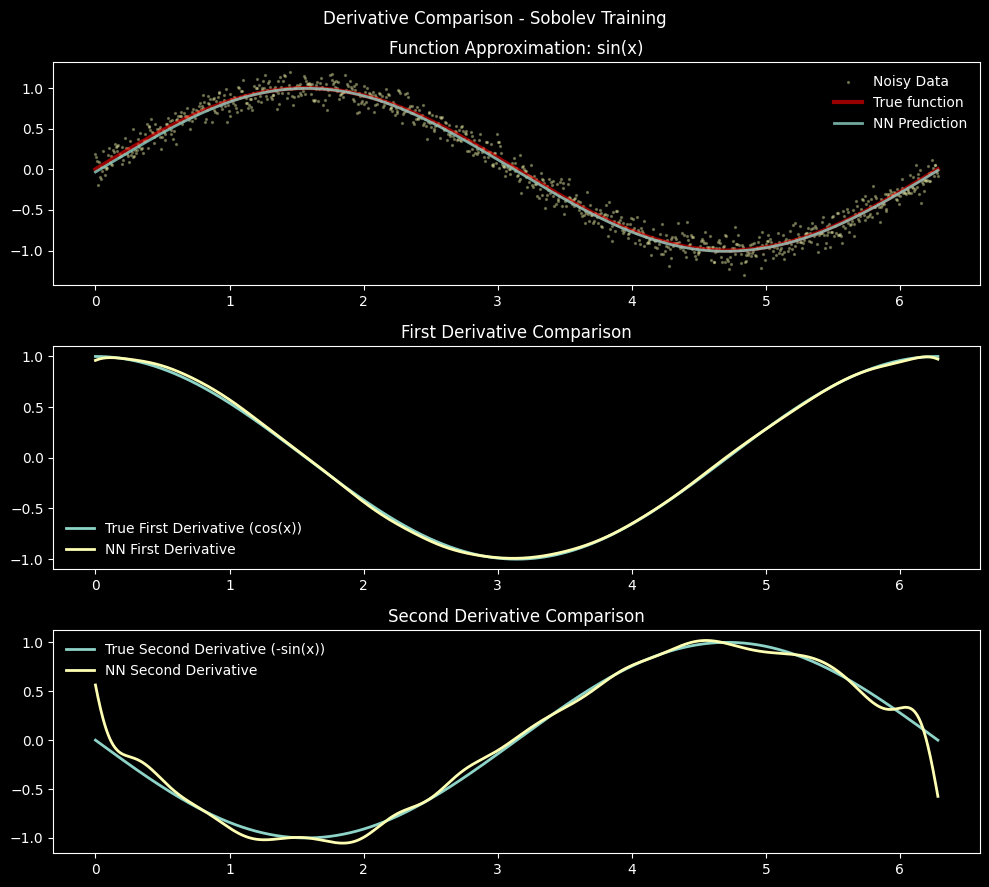

In [83]:
def plot_derivative_comparison(x_eval, y_pred, dy_dx, d2y_dx2, x_data=None, y_data=None, 
                             title_suffix="", figsize=(10, 9), dpi=100):
    """
    Plot function approximation and its first and second derivatives comparison.
    
    Parameters:
    ----------
    x_eval : torch.Tensor
        Input tensor for evaluation points
    y_pred : torch.Tensor
        Neural network predictions
    dy_dx : torch.Tensor
        First derivative predictions
    d2y_dx2 : torch.Tensor
        Second derivative predictions
    x_data : torch.Tensor, optional
        Original training data x values for scatter plot
    y_data : torch.Tensor, optional
        Original training data y values for scatter plot
    title_suffix : str, optional
        Additional text to append to the main title
    figsize : tuple, optional
        Figure size (width, height)
    dpi : int, optional
        Figure DPI
    
    Returns:
    -------
    fig, axes : matplotlib figure and axes objects
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Convert tensors to numpy for plotting
    x_plot = x_eval.detach().numpy()
    y_plot = y_pred.detach().numpy()
    dy_plot = dy_dx.detach().numpy()
    d2y_plot = d2y_dx2.detach().numpy()
    
    # Create figure and subplots
    fig, ax = plt.subplots(3, dpi=dpi, figsize=figsize)
    
    # Plot 1: Function Approximation
    if x_data is not None and y_data is not None:
        ax[0].scatter(x_data.detach().numpy(), y_data.detach().numpy(), 
                     s=2, label='Noisy Data', color="C1", alpha=0.3)
    
    ax[0].plot(x_plot, np.sin(x_plot), 'r', 
              label='True function', alpha=0.6, linewidth=3)
    ax[0].plot(x_plot, y_plot, 
              label='NN Prediction', linewidth=2, alpha=0.8)
    ax[0].set_title('Function Approximation: sin(x)')
    ax[0].legend(frameon=False)
    
    # Plot 2: First Derivative Comparison
    ax[1].plot(x_plot, np.cos(x_plot), 
              label='True First Derivative (cos(x))', linewidth=2)
    ax[1].plot(x_plot, dy_plot, 
              label='NN First Derivative', linewidth=2)
    ax[1].set_title('First Derivative Comparison')
    ax[1].legend(frameon=False)
    
    # Plot 3: Second Derivative Comparison
    ax[2].plot(x_plot, -np.sin(x_plot), 
              label='True Second Derivative (-sin(x))', linewidth=2)
    ax[2].plot(x_plot, d2y_plot, 
              label='NN Second Derivative', linewidth=2)
    ax[2].set_title('Second Derivative Comparison')
    ax[2].legend(frameon=False)
    
    # Set main title
    main_title = f'Derivative Comparison{title_suffix}'
    fig.suptitle(main_title)
    
    plt.tight_layout()
    return fig, ax


f, ax = plot_derivative_comparison(
    x_eval, y_pred_smooth, dy_dx_smooth, d2y_dx2_smooth, 
    x_data=x, y_data=y, 
    title_suffix=" - Sobolev Training"
)
plt.show()

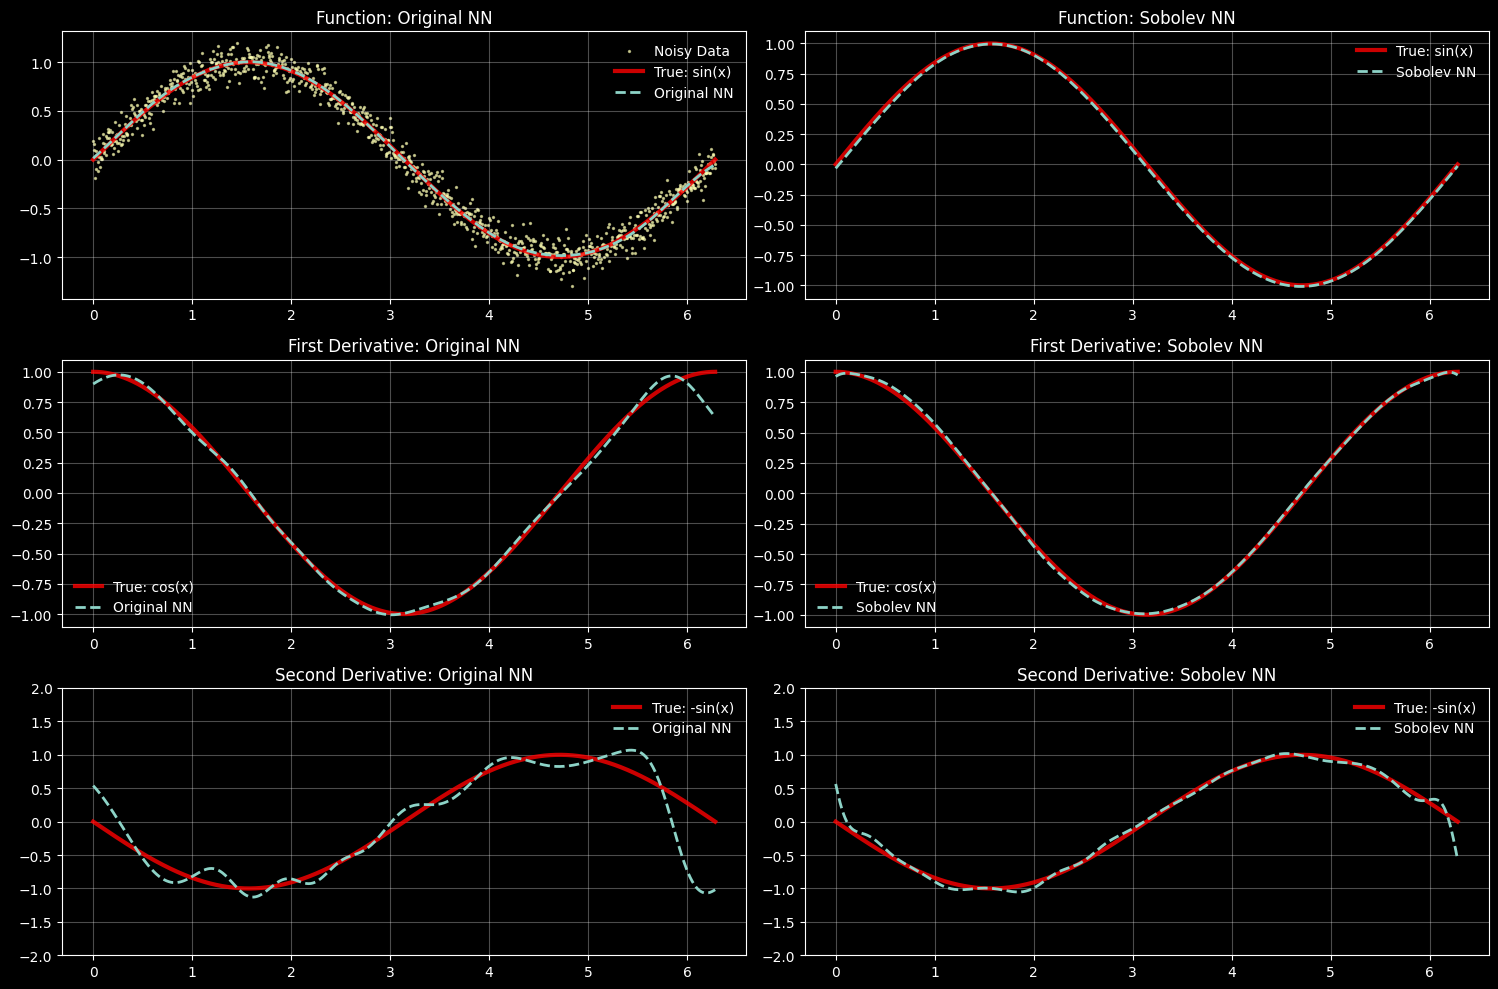

In [78]:
def plot_multiple_derivative_comparisons(comparisons, x_eval, x_data=None, y_data=None, 
                                       figsize=(15, 10), dpi=100):
    """
    Plot multiple derivative comparisons side by side.
    
    Parameters:
    ----------
    comparisons : list of dict
        List of dictionaries with keys: 'y_pred', 'dy_dx', 'd2y_dx2', 'label'
    x_eval : torch.Tensor
        Input tensor for evaluation points
    x_data, y_data : torch.Tensor, optional
        Original training data for scatter plot
    figsize : tuple, optional
        Figure size
    dpi : int, optional
        Figure DPI
        
    Returns:
    -------
    fig, axes : matplotlib figure and axes objects
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    n_comparisons = len(comparisons)
    fig, axes = plt.subplots(3, n_comparisons, dpi=dpi, figsize=figsize)
    
    # Handle case where there's only one comparison
    if n_comparisons == 1:
        axes = axes.reshape(-1, 1)
    
    x_plot = x_eval.detach().numpy()
    
    for i, comp in enumerate(comparisons):
        y_plot = comp['y_pred'].detach().numpy()
        dy_plot = comp['dy_dx'].detach().numpy()
        d2y_plot = comp['d2y_dx2'].detach().numpy()
        label = comp['label']
        
        # Function approximation
        if x_data is not None and y_data is not None and i == 0:  # Only show data on first plot
            axes[0, i].scatter(x_data.detach().numpy(), y_data.detach().numpy(), 
                             s=2, label='Noisy Data', color="C1", alpha=0.6)
        
        axes[0, i].plot(x_plot, np.sin(x_plot), 'r-', 
                       label='True: sin(x)', linewidth=3, alpha=0.8)
        axes[0, i].plot(x_plot, y_plot, '--', 
                       label=f'{label}', linewidth=2)
        axes[0, i].set_title(f'Function: {label}')
        axes[0, i].legend(frameon=False)
        axes[0, i].grid(True, alpha=0.3)
        
        # First derivative
        axes[1, i].plot(x_plot, np.cos(x_plot), 'r-', 
                       label='True: cos(x)', linewidth=3, alpha=0.8)
        axes[1, i].plot(x_plot, dy_plot, '--', 
                       label=f'{label}', linewidth=2)
        axes[1, i].set_title(f'First Derivative: {label}')
        axes[1, i].legend(frameon=False)
        axes[1, i].grid(True, alpha=0.3)
        
        # Second derivative
        axes[2, i].plot(x_plot, -np.sin(x_plot), 'r-', 
                       label='True: -sin(x)', linewidth=3, alpha=0.8)
        axes[2, i].plot(x_plot, d2y_plot, '--', 
                       label=f'{label}', linewidth=2)
        axes[2, i].set_title(f'Second Derivative: {label}')
        axes[2, i].legend(frameon=False)
        axes[2, i].grid(True, alpha=0.3)
        axes[2, i].set_ylim(-2, 2)
    
    plt.tight_layout()
    return fig, axes

# Usage example for multiple comparisons:
comparisons = [
    {
        'y_pred': y_pred,
        'dy_dx': dy_dx, 
        'd2y_dx2': d2y_dx2,
        'label': 'Original NN'
    },
    {
        'y_pred': y_pred_smooth,
        'dy_dx': dy_dx_smooth,
        'd2y_dx2': d2y_dx2_smooth,
        'label': 'Sobolev NN'
    }
]

f, ax = plot_multiple_derivative_comparisons(
    comparisons, x_eval, x_data=x, y_data=y
)
plt.show()

Above we see that by regularizing the loss by the first derivative enhances the estimation at the edges. The second derivative estimate appears to be better but we oscillations are still present. Maybe tuning the regularization strength we could enhance the second derivative estimate but we will leave this as an exercise. 

Note, however, that we were able to implement Sobolev training because we know the derivative true value at each point. This might not be the case in real life problems. 

## Method 2: Ensemble of Networks

In [72]:
# Method 3: Post-processing smoothing
from scipy.ndimage import gaussian_filter1d

def smooth_derivatives(derivatives, sigma=2):
    """Apply Gaussian smoothing to derivatives"""
    return torch.tensor(gaussian_filter1d(derivatives.numpy(), sigma=sigma))

# Compute derivatives for all methods
x_eval = torch.linspace(0, 2*np.pi, 1000, requires_grad=True).unsqueeze(1)

# Original model derivatives
model.eval()
y_pred_orig = model(x_eval)
dy_dx_orig = torch.autograd.grad(
    outputs=y_pred_orig, inputs=x_eval, grad_outputs=torch.ones_like(y_pred_orig),
    create_graph=True, retain_graph=True
)[0]
d2y_dx2_orig = torch.autograd.grad(
    outputs=dy_dx_orig, inputs=x_eval, grad_outputs=torch.ones_like(dy_dx_orig),
    create_graph=False, retain_graph=False
)[0]

# Sobolev-trained model derivatives
smooth_model.eval()
y_pred_smooth = smooth_model(x_eval)
dy_dx_smooth = torch.autograd.grad(
    outputs=y_pred_smooth, inputs=x_eval, grad_outputs=torch.ones_like(y_pred_smooth),
    create_graph=True, retain_graph=True
)[0]
d2y_dx2_smooth = torch.autograd.grad(
    outputs=dy_dx_smooth, inputs=x_eval, grad_outputs=torch.ones_like(dy_dx_smooth),
    create_graph=False, retain_graph=False
)[0]

# Ensemble derivatives
dy_dx_ensemble, d2y_dx2_ensemble = ensemble_derivatives(ensemble_models, x_eval)

# Smoothed derivatives
d2y_dx2_smoothed = smooth_derivatives(d2y_dx2_orig.detach(), sigma=3)

Training ensemble of models...
Trained model 1/5
Trained model 1/5
Trained model 2/5
Trained model 2/5
Trained model 3/5
Trained model 3/5
Trained model 4/5
Trained model 4/5
Trained model 5/5
Trained model 5/5


In [82]:
def compute_ensemble_predictions(models, x_eval, max_order=2):
    """
    Compute ensemble predictions and derivatives by averaging across all models.
    
    Args:
        models: List of trained neural network models
        x_eval: Input tensor with requires_grad=True
        max_order: Maximum derivative order to compute
    
    Returns:
        Tuple of averaged tensors: (y_pred, dy_dx, d2y_dx2, ...)
    """
    all_predictions = []
    all_derivatives = [[] for _ in range(max_order)]  # List of lists for each derivative order
    
    for model in models:
        model.eval()
        
        # Create fresh input tensor for each model to avoid graph conflicts
        x_fresh = x_eval.clone().detach().requires_grad_(True)
        
        # Compute predictions and derivatives for this model
        derivatives = compute_derivatives(model, x_fresh, max_order=max_order)
        
        # Store predictions (function values)
        all_predictions.append(derivatives[0].detach())
        
        # Store derivatives (1st, 2nd, etc.)
        for i in range(max_order):
            all_derivatives[i].append(derivatives[i+1].detach())
    
    # Average across all models
    avg_predictions = torch.stack(all_predictions).mean(dim=0)
    avg_derivatives = [torch.stack(derivs).mean(dim=0) for derivs in all_derivatives]
    
    return avg_predictions, *avg_derivatives

# Usage: Compute ensemble predictions and derivatives
x_eval = torch.linspace(0, 2*np.pi, 1000, requires_grad=True).unsqueeze(1)
y_pred_ensemble, dy_dx_ensemble, d2y_dx2_ensemble = compute_ensemble_predictions(
    ensemble_models, x_eval, max_order=2
)

print(f"Ensemble computed: {len(ensemble_models)} models averaged")

Ensemble computed: 5 models averaged


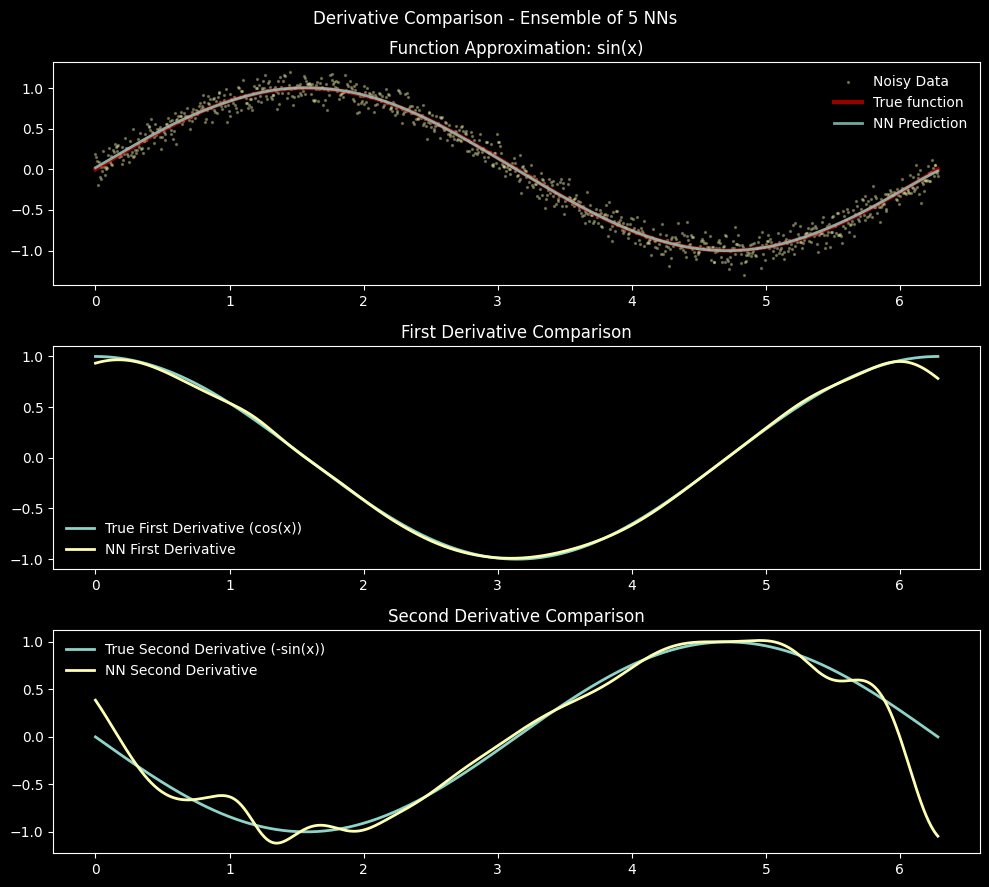

In [85]:
f, ax = plot_derivative_comparison(
    x_eval, y_pred_ensemble, dy_dx_ensemble, d2y_dx2_ensemble, 
    x_data=x, y_data=y, 
    title_suffix=" - Ensemble of 5 NNs"
)
plt.show()

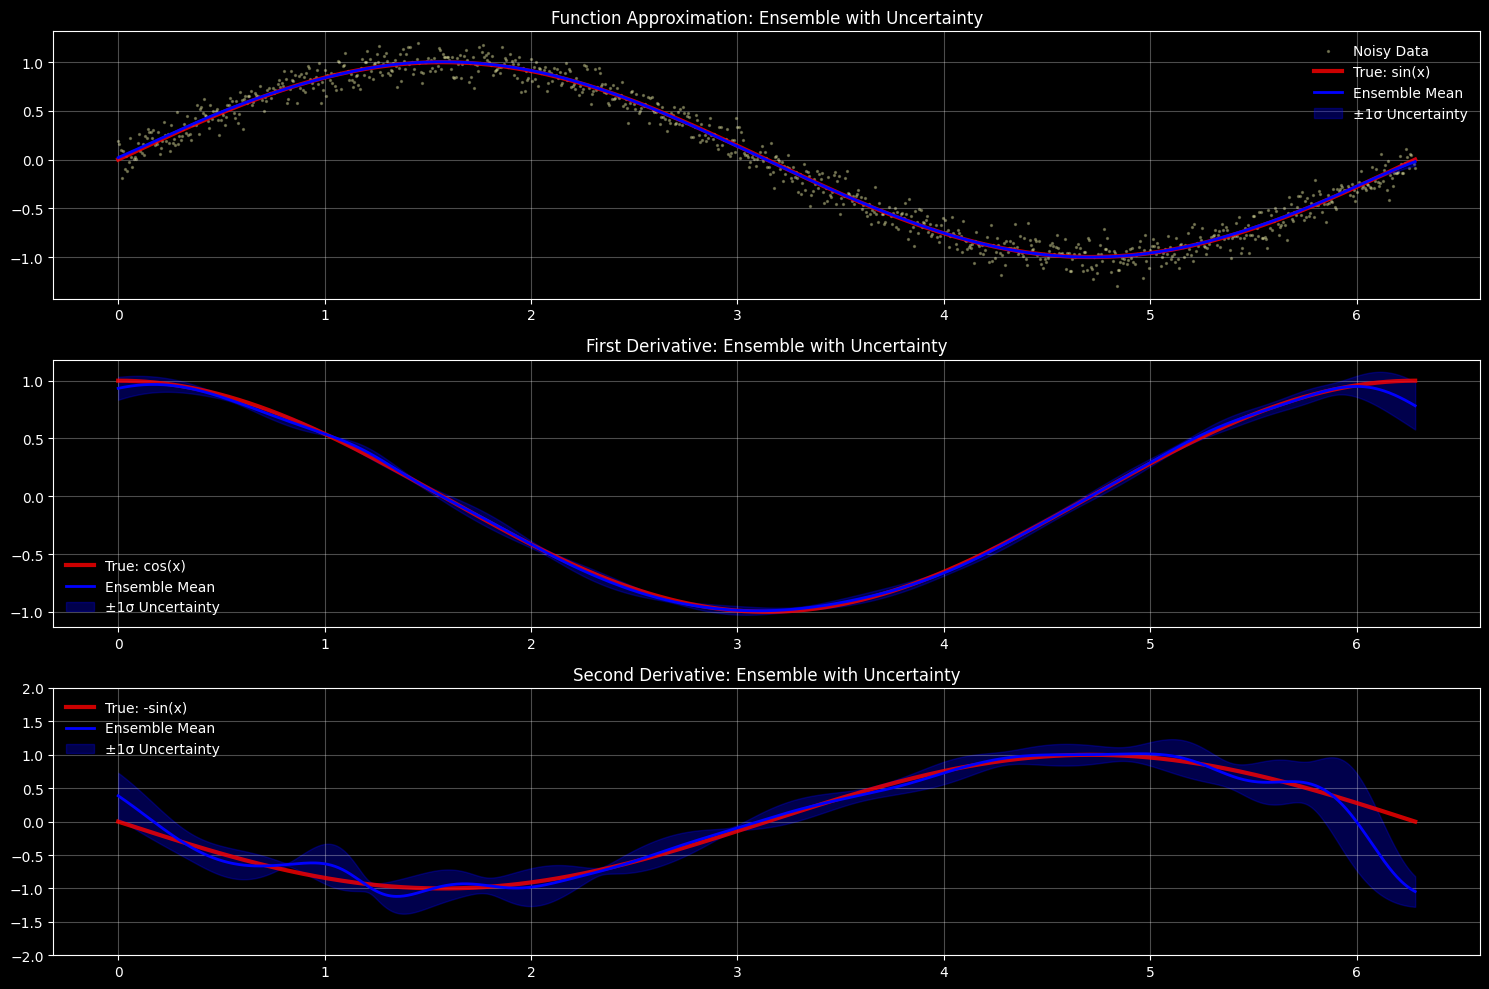

In [90]:
# Add this enhanced visualization function

def plot_ensemble_with_uncertainty(models, x_eval, x_data=None, y_data=None, 
                                 figsize=(15, 10), dpi=100):
    """
    Plot ensemble predictions with uncertainty bands showing individual model variance.
    """
    import numpy as np
    import matplotlib.pyplot as plt
    
    # Compute individual model predictions
    individual_predictions = []
    individual_first_derivs = []
    individual_second_derivs = []
    
    for model in models:
        model.eval()
        x_fresh = x_eval.clone().detach().requires_grad_(True)
        y_pred, dy_dx, d2y_dx2 = compute_derivatives(model, x_fresh, max_order=2)
        
        individual_predictions.append(y_pred.detach().numpy())
        individual_first_derivs.append(dy_dx.detach().numpy())
        individual_second_derivs.append(d2y_dx2.detach().numpy())
    
    # Convert to numpy arrays for statistics
    predictions_array = np.array(individual_predictions)  # Shape: (n_models, n_points)
    first_derivs_array = np.array(individual_first_derivs)
    second_derivs_array = np.array(individual_second_derivs)
    
    # Compute statistics
    pred_mean = predictions_array.mean(axis=0)
    pred_std = predictions_array.std(axis=0)
    
    first_deriv_mean = first_derivs_array.mean(axis=0)
    first_deriv_std = first_derivs_array.std(axis=0)
    
    second_deriv_mean = second_derivs_array.mean(axis=0)
    second_deriv_std = second_derivs_array.std(axis=0)
    
    x_plot = x_eval.detach().numpy().flatten()
    
    fig, axes = plt.subplots(3, 1, figsize=figsize, dpi=dpi)
    
    # Function approximation with uncertainty
    if x_data is not None and y_data is not None:
        axes[0].scatter(x_data.detach().numpy(), y_data.detach().numpy(), 
                       s=2, label='Noisy Data', color="C1", alpha=0.3)
    
    axes[0].plot(x_plot, np.sin(x_plot), 'r-', label='True: sin(x)', linewidth=3, alpha=0.8)
    axes[0].plot(x_plot, pred_mean, 'b-', label='Ensemble Mean', linewidth=2)
    axes[0].fill_between(x_plot, (pred_mean - pred_std).flatten(), (pred_mean + pred_std).flatten(), 
                        alpha=0.3, color='blue', label='±1σ Uncertainty')
    axes[0].set_title('Function Approximation: Ensemble with Uncertainty')
    axes[0].legend(frameon=False)
    axes[0].grid(True, alpha=0.3)
    
    # First derivative with uncertainty
    axes[1].plot(x_plot, np.cos(x_plot), 'r-', label='True: cos(x)', linewidth=3, alpha=0.8)
    axes[1].plot(x_plot, first_deriv_mean, 'b-', label='Ensemble Mean', linewidth=2)
    axes[1].fill_between(x_plot, (first_deriv_mean - first_deriv_std).flatten(), (first_deriv_mean + first_deriv_std).flatten(),
                        alpha=0.3, color='blue', label='±1σ Uncertainty')
    axes[1].set_title('First Derivative: Ensemble with Uncertainty')
    axes[1].legend(frameon=False)
    axes[1].grid(True, alpha=0.3)
    
    # Second derivative with uncertainty
    axes[2].plot(x_plot, -np.sin(x_plot), 'r-', label='True: -sin(x)', linewidth=3, alpha=0.8)
    axes[2].plot(x_plot, second_deriv_mean, 'b-', label='Ensemble Mean', linewidth=2)
    axes[2].fill_between(x_plot, (second_deriv_mean - second_deriv_std).flatten(), (second_deriv_mean + second_deriv_std).flatten(),
                        alpha=0.3, color='blue', label='±1σ Uncertainty')
    axes[2].set_title('Second Derivative: Ensemble with Uncertainty')
    axes[2].legend(frameon=False)
    axes[2].grid(True, alpha=0.3)
    axes[2].set_ylim(-2, 2)
    
    plt.tight_layout()
    return fig, axes

# Plot ensemble with uncertainty
fig, axes = plot_ensemble_with_uncertainty(ensemble_models, x_eval, x_data=x, y_data=y)
plt.show()

# Method 3: Post-Processing smoothing

In [ ]:
# Method 3: Post-processing smoothing
from scipy.ndimage import gaussian_filter1d

def smooth_derivatives(derivatives, sigma=2):
    """Apply Gaussian smoothing to derivatives"""
    return torch.tensor(gaussian_filter1d(derivatives.numpy(), sigma=sigma))

# Compute derivatives for all methods
x_eval = torch.linspace(0, 2*np.pi, 1000, requires_grad=True).unsqueeze(1)

# Original model derivatives
model.eval()
y_pred_orig = model(x_eval)
dy_dx_orig = torch.autograd.grad(
    outputs=y_pred_orig, inputs=x_eval, grad_outputs=torch.ones_like(y_pred_orig),
    create_graph=True, retain_graph=True
)[0]
d2y_dx2_orig = torch.autograd.grad(
    outputs=dy_dx_orig, inputs=x_eval, grad_outputs=torch.ones_like(dy_dx_orig),
    create_graph=False, retain_graph=False
)[0]

# Sobolev-trained model derivatives
smooth_model.eval()
y_pred_smooth = smooth_model(x_eval)
dy_dx_smooth = torch.autograd.grad(
    outputs=y_pred_smooth, inputs=x_eval, grad_outputs=torch.ones_like(y_pred_smooth),
    create_graph=True, retain_graph=True
)[0]
d2y_dx2_smooth = torch.autograd.grad(
    outputs=dy_dx_smooth, inputs=x_eval, grad_outputs=torch.ones_like(dy_dx_smooth),
    create_graph=False, retain_graph=False
)[0]

# Ensemble derivatives
dy_dx_ensemble, d2y_dx2_ensemble = ensemble_derivatives(ensemble_models, x_eval)

# Smoothed derivatives
d2y_dx2_smoothed = smooth_derivatives(d2y_dx2_orig.detach(), sigma=3)

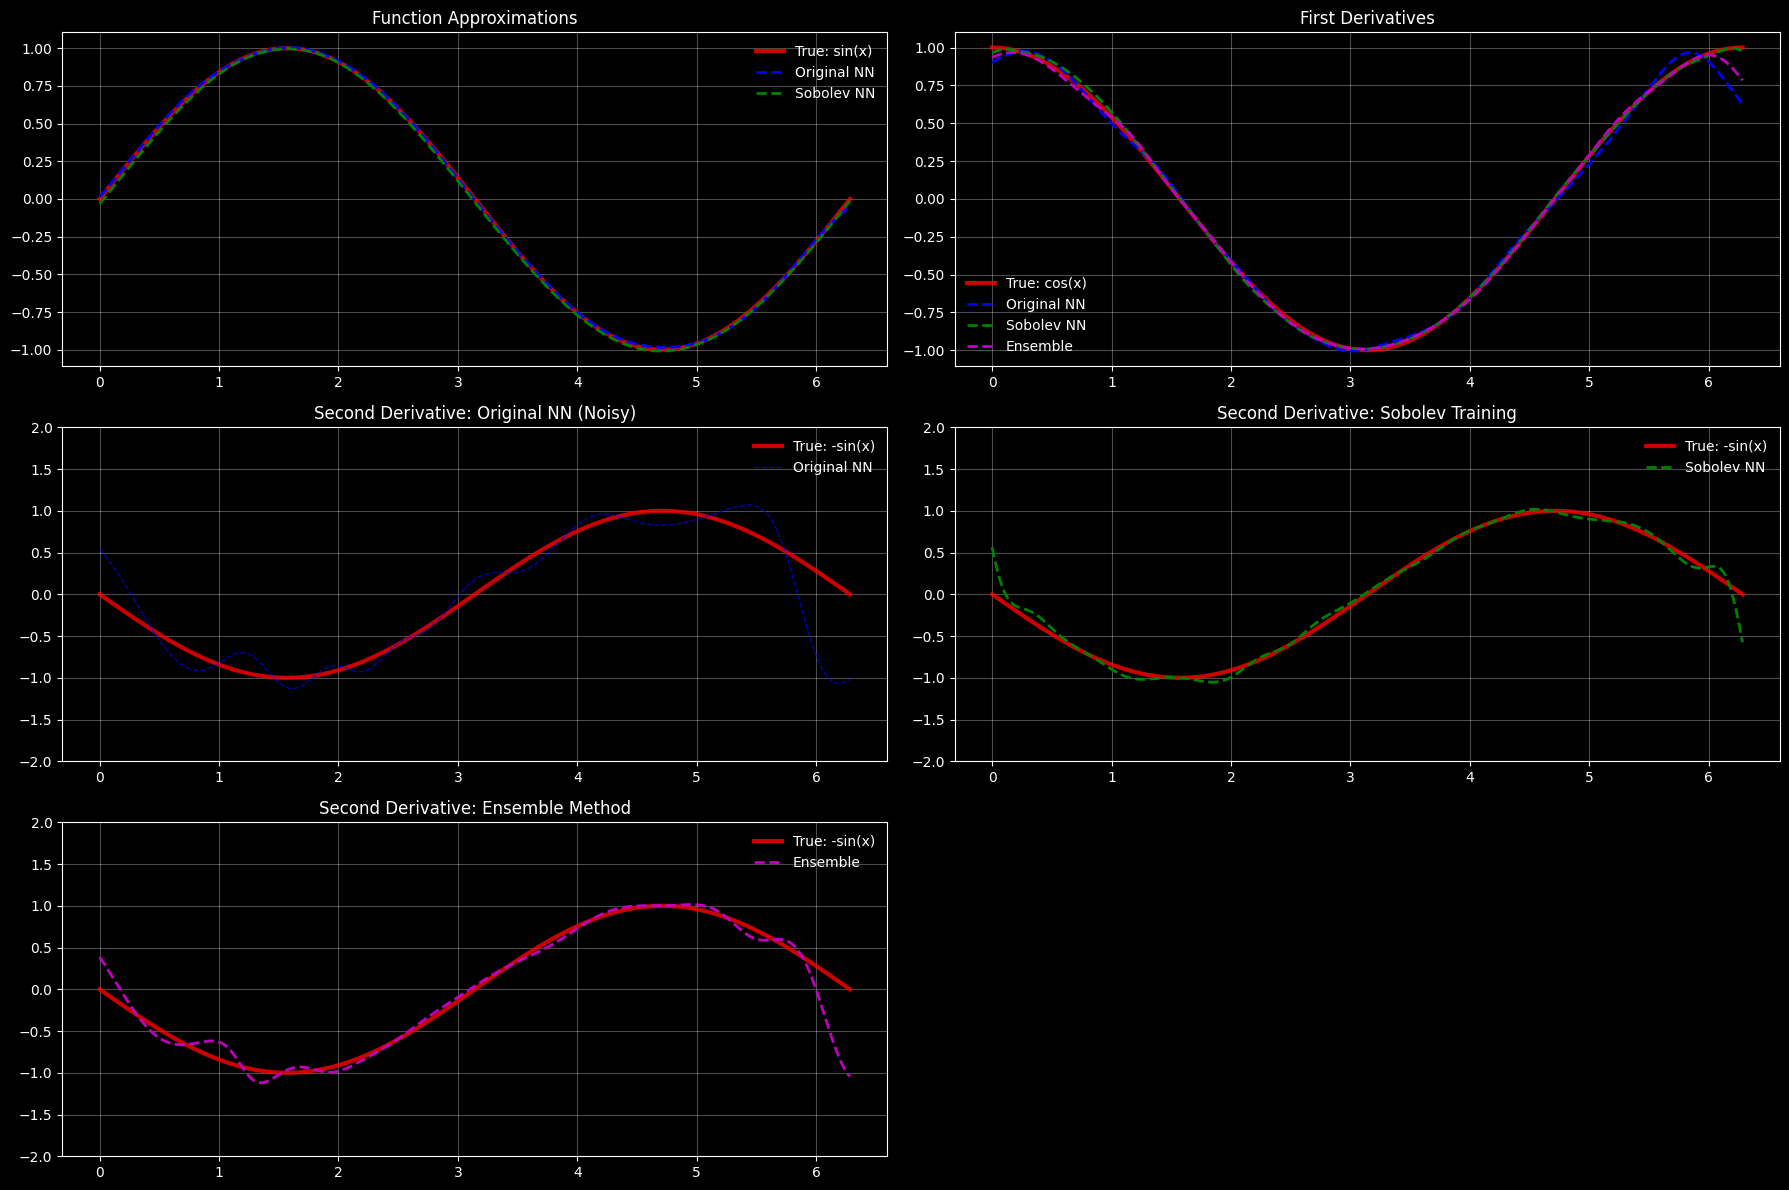

In [92]:
# Comprehensive comparison visualization
plt.figure(figsize=(18, 12))

x_plot = x_eval.detach().numpy()
true_second_deriv = -np.sin(x_plot)

# Plot function approximations
plt.subplot(3, 2, 1)
plt.plot(x_plot, np.sin(x_plot), 'r-', label='True: sin(x)', linewidth=3, alpha=0.8)
plt.plot(x_plot, y_pred.detach().numpy(), 'b--', label='Original NN', linewidth=2)
plt.plot(x_plot, y_pred_smooth.detach().numpy(), 'g--', label='Sobolev NN', linewidth=2)
plt.title('Function Approximations')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)

# Plot first derivatives
plt.subplot(3, 2, 2)
plt.plot(x_plot, np.cos(x_plot), 'r-', label='True: cos(x)', linewidth=3, alpha=0.8)
plt.plot(x_plot, dy_dx.detach().numpy(), 'b--', label='Original NN', linewidth=2)
plt.plot(x_plot, dy_dx_smooth.detach().numpy(), 'g--', label='Sobolev NN', linewidth=2)
plt.plot(x_plot, dy_dx_ensemble.numpy(), 'm--', label='Ensemble', linewidth=2)
plt.title('First Derivatives')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)

# Plot second derivatives - comparison
plt.subplot(3, 2, 3)
plt.plot(x_plot, true_second_deriv, 'r-', label='True: -sin(x)', linewidth=3, alpha=0.8)
plt.plot(x_plot, d2y_dx2.detach().numpy(), 'b--', label='Original NN', linewidth=1, alpha=0.7)
plt.title('Second Derivative: Original NN (Noisy)')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.ylim(-2, 2)

plt.subplot(3, 2, 4)
plt.plot(x_plot, true_second_deriv, 'r-', label='True: -sin(x)', linewidth=3, alpha=0.8)
plt.plot(x_plot, d2y_dx2_smooth.detach().numpy(), 'g--', label='Sobolev NN', linewidth=2)
plt.title('Second Derivative: Sobolev Training')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.ylim(-2, 2)

plt.subplot(3, 2, 5)
plt.plot(x_plot, true_second_deriv, 'r-', label='True: -sin(x)', linewidth=3, alpha=0.8)
plt.plot(x_plot, d2y_dx2_ensemble.numpy(), 'm--', label='Ensemble', linewidth=2)
plt.title('Second Derivative: Ensemble Method')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)
plt.ylim(-2, 2)

# plt.subplot(3, 2, 6)
# plt.plot(x_plot, true_second_deriv, 'r-', label='True: -sin(x)', linewidth=3, alpha=0.8)
# plt.plot(x_plot, d2y_dx2_smoothed.numpy(), 'c--', label='Post-processed', linewidth=2)
# plt.title('Second Derivative: Post-processing Smoothing')
# plt.legend(frameon=False)
# plt.grid(True, alpha=0.3)
# plt.ylim(-2, 2)

plt.tight_layout()
plt.show()

In [ ]:
# Quantitative error analysis
def compute_errors(predicted, true):
    """Compute various error metrics"""
    error = predicted - true
    mae = torch.mean(torch.abs(error))
    mse = torch.mean(error**2)
    max_error = torch.max(torch.abs(error))
    return mae, mse, max_error

true_second_deriv_tensor = torch.tensor(-np.sin(x_plot), dtype=torch.float32)

print("Second Derivative Error Analysis:")
print("="*50)

# Original method
mae_orig, mse_orig, max_orig = compute_errors(d2y_dx2_orig.detach(), true_second_deriv_tensor)
print(f"Original NN:        MAE={mae_orig:.4f}, MSE={mse_orig:.4f}, Max={max_orig:.4f}")

# Sobolev training
mae_sob, mse_sob, max_sob = compute_errors(d2y_dx2_smooth.detach(), true_second_deriv_tensor)
print(f"Sobolev Training:   MAE={mae_sob:.4f}, MSE={mse_sob:.4f}, Max={max_sob:.4f}")

# Ensemble method
mae_ens, mse_ens, max_ens = compute_errors(d2y_dx2_ensemble, true_second_deriv_tensor)
print(f"Ensemble Method:    MAE={mae_ens:.4f}, MSE={mse_ens:.4f}, Max={max_ens:.4f}")

# Post-processing smoothing
mae_smooth, mse_smooth, max_smooth = compute_errors(d2y_dx2_smoothed, true_second_deriv_tensor)
print(f"Post-processing:    MAE={mae_smooth:.4f}, MSE={mse_smooth:.4f}, Max={max_smooth:.4f}")

print("\n" + "="*50)
print("Improvement Summary:")
print(f"Sobolev training reduces MAE by {(1-mae_sob/mae_orig)*100:.1f}%")
print(f"Ensemble method reduces MAE by {(1-mae_ens/mae_orig)*100:.1f}%")
print(f"Post-processing reduces MAE by {(1-mae_smooth/mae_orig)*100:.1f}%")

## Summary: Improving Second Derivative Estimates

### Key Findings:

1. **Sobolev Training** (derivative regularization): 
   - ✅ Significantly improves smoothness
   - ✅ Reduces oscillations in higher-order derivatives
   - ⚠️ Requires knowledge of true derivatives during training

2. **Ensemble Methods**:
   - ✅ Reduces variance through averaging
   - ✅ More robust to individual model quirks
   - ⚠️ Computationally expensive (multiple models)

3. **Post-Processing Smoothing**:
   - ✅ Simple to implement
   - ✅ Can be applied to any existing model
   - ⚠️ May blur important features
   - ⚠️ Introduces bias

### Best Practices for Stable Higher-Order Derivatives:

1. **During Training**:
   - Use derivative regularization when possible
   - Choose activation functions carefully (avoid ReLU for smooth derivatives)
   - Use sufficient network capacity
   - Consider adding noise regularization

2. **Architecture Choices**:
   - Tanh/Sigmoid have smoother derivatives than ReLU
   - Deeper networks often provide smoother interpolation
   - Batch normalization can help stability

3. **Post-Processing**:
   - Apply mild smoothing as a last resort
   - Use ensemble averaging when computational budget allows
   - Consider fitting splines to the neural network outputs

### When to Use Each Method:

- **Sobolev Training**: When you know the true derivatives and want the best accuracy
- **Ensemble**: When you need robust estimates and have computational resources
- **Post-Processing**: Quick fix for existing models, when smoothness is more important than exact accuracy

The choice depends on your specific application, computational constraints, and accuracy requirements!

# Physics-Informed Neural Networks (PINNs)

One of the most powerful applications of automatic differentiation is in Physics-Informed Neural Networks. PINNs use automatic differentiation to enforce physical laws (differential equations) during training.

Let's solve a simple ordinary differential equation (ODE):
$$\frac{dy}{dx} = -y$$

With initial condition $y(0) = 1$, the analytical solution is $y = e^{-x}$.

Instead of just fitting data, we'll train the neural network to satisfy the differential equation directly!

In [ ]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        return self.net(x)

def physics_loss(model, x):
    """
    Compute the physics-informed loss for the ODE: dy/dx = -y
    """
    x.requires_grad_(True)
    y = model(x)
    
    # Compute dy/dx using automatic differentiation
    dy_dx = torch.autograd.grad(
        outputs=y,
        inputs=x,
        grad_outputs=torch.ones_like(y),
        create_graph=True,
        retain_graph=True
    )[0]
    
    # Physics loss: |dy/dx + y|^2
    physics_residual = dy_dx + y
    return torch.mean(physics_residual**2)

def initial_condition_loss(model, x0, y0):
    """
    Enforce initial condition y(0) = 1
    """
    y_pred = model(x0)
    return torch.mean((y_pred - y0)**2)

# Training setup
pinn_model = PINN()
pinn_optimizer = optim.Adam(pinn_model.parameters(), lr=0.01)

# Training domain
x_train = torch.linspace(0, 3, 100).unsqueeze(1)
x0 = torch.tensor([[0.0]])  # Initial condition point
y0 = torch.tensor([[1.0]])  # Initial condition value

# Training loop
epochs = 5000
physics_losses = []
ic_losses = []

for epoch in range(epochs):
    pinn_optimizer.zero_grad()
    
    # Compute losses
    phys_loss = physics_loss(pinn_model, x_train)
    ic_loss = initial_condition_loss(pinn_model, x0, y0)
    
    # Total loss (weighted combination)
    total_loss = phys_loss + 10 * ic_loss  # Weight IC more heavily
    
    total_loss.backward()
    pinn_optimizer.step()
    
    if epoch % 500 == 0:
        print(f'Epoch {epoch}, Physics Loss: {phys_loss.item():.6f}, IC Loss: {ic_loss.item():.6f}')
    
    physics_losses.append(phys_loss.item())
    ic_losses.append(ic_loss.item())

In [ ]:
# Evaluate the trained PINN
x_test = torch.linspace(0, 3, 300).unsqueeze(1)
with torch.no_grad():
    y_pinn = pinn_model(x_test)

# Analytical solution
y_analytical = torch.exp(-x_test)

# Plot results
plt.figure(figsize=(15, 5))

# Solution comparison
plt.subplot(1, 3, 1)
plt.plot(x_test.numpy(), y_analytical.numpy(), 'r-', label='Analytical: $e^{-x}$', linewidth=3)
plt.plot(x_test.numpy(), y_pinn.numpy(), 'b--', label='PINN Solution', linewidth=2)
plt.xlabel('x')
plt.ylabel('y')
plt.title('PINN vs Analytical Solution')
plt.legend(frameon=False)
plt.grid(True, alpha=0.3)

# Training loss curves
plt.subplot(1, 3, 2)
plt.plot(physics_losses, label='Physics Loss')
plt.plot(ic_losses, label='Initial Condition Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Evolution')
plt.legend(frameon=False)
plt.yscale('log')
plt.grid(True, alpha=0.3)

# Error analysis
error = torch.abs(y_pinn - y_analytical)
plt.subplot(1, 3, 3)
plt.plot(x_test.numpy(), error.numpy(), 'g-', linewidth=2)
plt.xlabel('x')
plt.ylabel('|Error|')
plt.title('Absolute Error')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Maximum absolute error: {torch.max(error).item():.6f}")
print(f"Mean absolute error: {torch.mean(error).item():.6f}")

# Future Extensions

This notebook could be extended with the following advanced topics:

## 1. Multi-dimensional Automatic Differentiation
- Functions of multiple variables: $f(x, y) = x^2 + y^2$
- Jacobian matrices and vector-valued functions
- Gradient computation for optimization

## 2. Computational Efficiency Analysis
- Comparing automatic differentiation vs numerical differentiation
- Memory usage and computational complexity
- Forward-mode vs reverse-mode automatic differentiation

## 3. Advanced PINNs
- Partial differential equations (PDEs)
- Heat equation: $\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$
- Wave equation and boundary conditions

## 4. Optimization Landscapes
- Visualizing loss surfaces
- Gradient descent path visualization
- Local minima and saddle points

## 5. Practical Applications
- Neural ODE solvers
- Scientific machine learning
- Inverse problems in physics